# Roller Tank Processing Codes Final Version 5/12/26
## Author: Ashely Kraekel, Dazhi Li

### How this works
1. Settings
   - General setup, this version uses only 1 frame per timepoint, the actual used code averages data over 60 frames (30 before and 30 after the time point)
   - Has the volume of the liquid in the tnak, use to change mL/L to L
   - Where the images are stored and where the results are saved
2. Calibration
   - The calibration value tells the code how many microns correspond to one pixel.
   - The mask settings define the circular region of the image that should be analyzed. Since the roller tank is circular in the image, the mask removes everything outside the useful circular region.
   - The threshold value controls how the grayscale image is converted into a black-and-white image. Bright pixels above the threshold are treated as possible particles.
   - The minimum particle area removes very small detections that are likely noise.  
3. Image Processing
   - Read the original image
   - Apply a mask
   - Convert into greyscale
   - Apply binary threashold
   - Detect contours
   - Filter out noise
   - Find properties
   - Draw contours of valid particles
4. Contouring
   - Shows the process in 3   
5. Data Processing
   - For each detected particle, the code uses the particle area to calculate an equivalent spherical diameter. Then it assumes the particle is spherical and calculates its volume.
   - The volume of each detected particle is added together to get the total particle volume for that image.
   - Then the total volume is converted from mL into mL/L using the tank volume.
   - The processed data is saved as a CSV file in the output folder.
6. Graphing
   - The graphing section reads the processed data and creates a plot of total particle volume versus time.
   - X-axis in hours, and Y-axis in total volume in mL/L
   - The slope tells how quickly the total detected particle volume changes over time.
  
### Running Instructions

- This code is set up to pull from a folder called **Roller Tank Images** placed in the **Desktop**, in **Roller Tank Images**, folders like **CTD_"number"_"DEEP or SHALLOW"_agg_frames**, inside the images are named like **Agg_SlowCam_"frame number"**.

- This code automatically assigns time points from 0 to 4 hour using the frame number in the image names

### Imports

In [30]:
from google.colab import drive
import os
import re
import csv
import random
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from skimage import img_as_ubyte

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Settings
##### "average60" = average the first 60 frames per 30-minute timepoint (30 frames before and 30 frames after the timepoint), this is how the original graph was made
##### "single"    = process one frame per 30-minute timepoint

It is currently in single mode, to use it in average60 mode, inside **CTD_"number"_"DEEP or SHALLOW"_agg_frames**, there needs to be folders titled **0hr**, **0.5hr**, **1hr**,..., **4hr**, in those folders is where 60 frames will need to be.

**Input your image folder address at `CTD_IMAGE_FOLDER_ADRESS`, place the your folder in My Drive in Google Drive.**

**In the line below, you need to input the overall address of the folder**

In [31]:
|PROCESSING_MODE = "single"

FRAME_LIMIT = 60
SINGLE_FRAME_NUMBER = 1

Show_Images = False
Show_ID = True

# tank volume conversion
liquid_volume_liters = 0.07854

# input address
CTD_IMAGE_FOLDER_ADDRESS = r"/content/drive/MyDrive/Roller Tank Images/CTD_010_DEEP_agg_frames"

sys.path.insert(0, str(r"/content/drive/MyDrive/Roller Tank Images"
))
from rotating_calipers import min_max_feret

ctd_image_folder_path = Path(CTD_IMAGE_FOLDER_ADDRESS)

# Use the folder name as the CTD name
CTD_NAME = ctd_image_folder_path.name.replace("_agg_frames", "")

output_folder = ctd_image_folder_path.parent / "output"
output_folder.mkdir(parents=True, exist_ok=True)

# contour image settings
SHOW_CONTOUR_CHECKS = True
SAVE_CONTOUR_CHECKS = True

### Calibration Settings

In [32]:
# calibration data for each set, camera settings, microns per pixels (I'm pretty sure)
calibration_data = {
    "Set1": 29.1
    # "Set1": 29.358,
    # "Set2": 30.023,
    # "Set3": 28.98
}

# mask for greyscale
mask_params = [
    {"center_x": 2900, "center_y": 1875, "radius": 1650},  # Set1
    # {"center_x": 2100, "center_y": 1450, "radius": 1300},  # Set2
]

# thresholding for greyscale (dynamic thresholding failed)
threshold_data = {
    "Set1": 100,
    # "Set2": 190,
    # "Set3": 175
}

min_particle_area = 5


### Image Processing

In [33]:
def read_images_from_dir(directory, skip=1):
    image_files = []
    sorted_files = sorted(
        os.listdir(directory),
        key=lambda x: int(x.split('_')[-1]) if x.endswith('.bmp') and x.split('_')[-1].isdigit() else float('inf')
    )
    for idx, filename in enumerate(sorted_files):
        if idx == 0 or idx % skip == 0:
            image_files.append(os.path.join(directory, filename))
    return image_files

def apply_fixed_mask(image_path, mask_center_x, mask_center_y, mask_radius):
    # Read in image
    original_image = cv2.imread(image_path)

    # Define Tube Mask function
    def tube_mask(image, center, radius):
        # Initialize mask
        mask = np.zeros_like(image)
        # Draw circle for mask
        cv2.circle(mask, center, radius, (255, 255, 255), -1)
        # Use mask to blackout particles outside of mask
        masked_image = cv2.bitwise_and(image, mask)
        return masked_image

    # Use specified sizes to make mask
    masked_image = tube_mask(original_image, (mask_center_x, mask_center_y), mask_radius)

    return masked_image

def process_image(image, um_per_px, threshold_value):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
    binary = img_as_ubyte(binary)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_image = np.zeros_like(image)

    # List to store particle areas and centroids
    particle_data = []

    # Particle Id
    particle_id = 1

    # Draw contours without filling for particles
    for contour in contours:
        area = cv2.contourArea(contour)
        # Make sure area is greater than threshold area
        if area > min_particle_area:
            # Ellipse needs at least 5 countour points
            if len(contour) >= 5:
                # Convert pixel area to real-world area
                area_um = area * (um_per_px ** 2)

                # Centroid
                M = cv2.moments(contour)
                centroid_x = int(M["m10"] / M["m00"])
                centroid_y = int(M["m01"] / M["m00"])

                # Perimeter
                perimeter = cv2.arcLength(contour, True)
                perimeter_um = perimeter * um_per_px

                # Ellipse Properties
                ellipse = cv2.fitEllipse(contour)
                major_axis_length = max(ellipse[1])
                major_axis_length_um = major_axis_length * um_per_px
                minor_axis_length = min(ellipse[1])
                minor_axis_length_um = minor_axis_length * um_per_px
                angle = ellipse[2]

                # Aspect ratio
                if minor_axis_length_um > 0:
                    aspect_ratio = major_axis_length_um / minor_axis_length_um
                else:
                    aspect_ratio = 0

                # Circularity
                circularity_um = (4 * np.pi * area_um) / (perimeter_um ** 2)

                # Calculate Feret diameters and angles
                boundary_points = [tuple(point[0]) for point in contour]
                min_feret, min_feret_angle, max_feret, max_feret_angle = min_max_feret(boundary_points)

                min_feret_um = min_feret * um_per_px
                max_feret_um = max_feret * um_per_px

                # Append particle data to the list
                particle_data.append({
                    'Particle ID': particle_id,
                    'Area (microns^2)': area_um,
                    'Centroid_X (pixels)': centroid_x,
                    'Centroid_Y (pixels)': centroid_y,
                    'Perimeter (um)': perimeter_um,
                    'Major Axis Length (um)': major_axis_length_um,
                    'Minor Axis Length (um)': minor_axis_length_um,
                    'Angle of Rotation (degrees)': angle,
                    'Circularity': circularity_um,
                    'Aspect Ratio': aspect_ratio,
                    'MinFeret (um)': min_feret_um,
                    'Min Feret Angle (degrees)': min_feret_angle,
                    'MaxFeret (um)': max_feret_um,
                    'Max Feret Angle (degrees)': max_feret_angle,
                    'Calibration (um_per_px)': um_per_px,
                    'Threshold': threshold_value
                })

                # Random color for drawing contours
                random_color = (
                    random.randint(0, 255),
                    random.randint(0, 255),
                    random.randint(0, 255)
                )
                cv2.drawContours(contour_image, [contour], -1, random_color, thickness=2)

                if Show_ID:
                    # Draw particle ID on top of each particle with the same random color
                    cv2.putText(
                        contour_image,
                        str(particle_id),
                        (centroid_x, centroid_y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        1,
                        random_color,
                        2
                    )

                particle_id += 1

    return contour_image, particle_data

### Data Processing

In [34]:

def calculate_esd(area_microns_squared):
    return np.sqrt((4 / np.pi) * area_microns_squared)


def calculate_volume_mL(esd_um):
    volume_um3 = (4 / 3) * np.pi * (esd_um / 2) ** 3
    volume_mL = volume_um3 / 1e12
    return volume_mL


def get_ctd_name_from_frame_folder(folder_name):
    return folder_name.replace("_agg_frames", "")


def get_processed_csv_path():
    if PROCESSING_MODE == "average60":
        return output_folder / "ctd_total_volume_60frame_average.csv"

    elif PROCESSING_MODE == "single":
        return output_folder / "ctd_total_volume_singleframe.csv"


def extract_image_number(image_filename):
    """
    Example:
    Agg_SlowCam_10.bmp   -> 10
    Agg_SlowCam_900.bmp  -> 900
    Agg_SlowCam_1800.bmp -> 1800
    """
    numbers = re.findall(r"\d+", image_filename)

    if len(numbers) == 0:
        return None

    return int(numbers[-1])


def find_timepoint_images(frame_folder):

    image_files = []

    for filename in os.listdir(frame_folder):
        file_path = frame_folder / filename

        if not file_path.is_file():
            continue

        if file_path.suffix.lower() != ".bmp":
            continue

        image_number = extract_image_number(filename)

        if image_number is None:
            continue

        image_files.append((image_number, filename, file_path))

    image_files = sorted(image_files, key=lambda x: x[0])

    timepoint_images = []

    for index, (image_number, filename, file_path) in enumerate(image_files):
        time_hr = index * 0.5

        timepoint_images.append({
            "Time_hr": time_hr,
            "Time_Label": f"{time_hr:g}hr",
            "Image_Number": image_number,
            "Image_File": filename,
            "Image_Path": file_path
        })

    return timepoint_images


def process_one_image_timepoint(CTD_NAME, timepoint):
    time_hr = timepoint["Time_hr"]
    time_label = timepoint["Time_Label"]
    image_path = timepoint["Image_Path"]

    print()
    print(f"Processing {CTD_NAME}, {time_label}")
    print(f"Image file: {image_path.name}")

    # Uses original notebook Set1 settings
    set_name = "Set1"
    um_per_px = calibration_data[set_name]
    threshold_value = threshold_data[set_name]

    mask_center_x = mask_params[0]["center_x"]
    mask_center_y = mask_params[0]["center_y"]
    mask_radius = mask_params[0]["radius"]

    # Original image masking function
    masked_image = apply_fixed_mask(
        str(image_path),
        mask_center_x,
        mask_center_y,
        mask_radius
    )

    # Original image processing / contouring function
    processed_image, particle_data_single = process_image(
        masked_image,
        um_per_px,
        threshold_value
    )

    total_volume_this_frame_mL = 0

    for particle in particle_data_single:
        area_microns_squared = particle["Area (microns^2)"]
        esd_um = calculate_esd(area_microns_squared)
        volume_mL = calculate_volume_mL(esd_um)

        total_volume_this_frame_mL += volume_mL

    total_volume_mL_per_L = total_volume_this_frame_mL / liquid_volume_liters

    return {
        "CTD": CTD_NAME,
        "Time_hr": time_hr,
        "Time_Label": time_label,
        "Image_Number": timepoint["Image_Number"],
        "Image_File": timepoint["Image_File"],
        "Frames_Used": 1,
        "Average_Total_Volume_mL": total_volume_this_frame_mL,
        "Average_Total_Volume_mL_per_L": total_volume_mL_per_L
    }


def process_all_ctds():
    if not ctd_image_folder_path.exists():
        print(f"CTD image folder does not exist: {ctd_image_folder_path}")
        return pd.DataFrame()

    if not ctd_image_folder_path.is_dir():
        print(f"This is not a folder: {ctd_image_folder_path}")
        return pd.DataFrame()

    timepoint_images = find_timepoint_images(ctd_image_folder_path)

    if len(timepoint_images) == 0:
        print(f"No BMP images found in: {ctd_image_folder_path}")
        return pd.DataFrame()

    print()
    print(f"Processing CTD folder: {ctd_image_folder_path}")
    print(f"CTD name: {CTD_NAME}")
    print(f"Found {len(timepoint_images)} timepoint images")

    all_results = []

    for timepoint in timepoint_images:
        result = process_one_image_timepoint(
            CTD_NAME=CTD_NAME,
            timepoint=timepoint
        )

        if result is not None:
            all_results.append(result)

    results_df = pd.DataFrame(all_results)

    if len(results_df) == 0:
        print("No results were generated.")
        return results_df

    results_df = results_df.sort_values(["CTD", "Time_hr"]).reset_index(drop=True)

    output_csv_path = get_processed_csv_path()
    results_df.to_csv(output_csv_path, index=False)

    print()
    print(f"Processed data saved to: {output_csv_path}")

    return results_df

In [35]:
results_df = process_all_ctds()


Processing CTD folder: /content/drive/MyDrive/Roller Tank Images/CTD_010_DEEP_agg_frames
CTD name: CTD_010_DEEP
Found 3 timepoint images

Processing CTD_010_DEEP, 0hr
Image file: Agg_SlowCam_10.bmp

Processing CTD_010_DEEP, 0.5hr
Image file: Agg_SlowCam_1800.bmp

Processing CTD_010_DEEP, 1hr
Image file: Agg_SlowCam_2700.bmp

Processed data saved to: /content/drive/MyDrive/Roller Tank Images/output/ctd_total_volume_singleframe.csv


### Contouring

In [36]:
def extract_image_number(image_filename):
    numbers = re.findall(r"\d+", image_filename)

    if len(numbers) == 0:
        return None

    return int(numbers[-1])


def get_sorted_bmp_files(ctd_folder_path):
    bmp_files = []

    for filename in os.listdir(ctd_folder_path):
        file_path = ctd_folder_path / filename

        if not file_path.is_file():
            continue

        if file_path.suffix.lower() != ".bmp":
            continue

        image_number = extract_image_number(filename)

        if image_number is None:
            continue

        bmp_files.append((image_number, filename, file_path))

    bmp_files = sorted(bmp_files, key=lambda x: x[0])

    return bmp_files


def make_contouring_check_image(
    CTD_FOLDER_NAME,
    image_path,
    time_hr,
    SAVE_IMAGE=True,
    SHOW_IMAGE=True
):
    print()
    print(f"Creating contour check for {CTD_FOLDER_NAME}, {time_hr:g} hr")
    print(f"Image: {image_path.name}")

    # Use original notebook Set1 settings
    set_name = "Set1"
    um_per_px = calibration_data[set_name]
    threshold_value = threshold_data[set_name]

    mask_center_x = mask_params[0]["center_x"]
    mask_center_y = mask_params[0]["center_y"]
    mask_radius = mask_params[0]["radius"]

    # Original image
    original_image = cv2.imread(str(image_path))

    if original_image is None:
        print(f"Could not read image: {image_path}")
        return None, None

    # Original masking function
    masked_image = apply_fixed_mask(
        str(image_path),
        mask_center_x,
        mask_center_y,
        mask_radius
    )

    # Recreate grayscale and binary only for visualization
    gray = cv2.cvtColor(masked_image, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    binary = img_as_ubyte(binary)

    # Original contouring / image-processing function
    processed_image, particle_data_single = process_image(
        masked_image,
        um_per_px,
        threshold_value
    )

    # Convert BGR to RGB for matplotlib
    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB)
    contour_rgb = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

    overlay_rgb = cv2.addWeighted(
        masked_rgb,
        0.75,
        contour_rgb,
        1.0,
        0
    )

    # Plot the same 5-step image you showed
    fig, axes = plt.subplots(1, 5, figsize=(24, 5))

    axes[0].imshow(original_rgb)
    axes[0].set_title("1. Original Image")

    axes[1].imshow(masked_rgb)
    axes[1].set_title("2. Circular Mask Applied")

    axes[2].imshow(gray, cmap="gray")
    axes[2].set_title("3. Grayscale")

    axes[3].imshow(binary, cmap="gray")
    axes[3].set_title(f"4. Binary Threshold = {threshold_value}")

    axes[4].imshow(overlay_rgb)
    axes[4].set_title(
        f"5. Final Contours\nParticles = {len(particle_data_single)}"
    )

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{CTD_FOLDER_NAME} | {image_path.name} | Time = {time_hr:g} hr",
        fontsize=14
    )

    plt.tight_layout()

    if SAVE_IMAGE:
        contour_check_folder = output_folder / "contour_checks"
        contour_check_folder.mkdir(parents=True, exist_ok=True)

        safe_time = str(time_hr).replace(".", "p")

        save_path = (
            contour_check_folder /
            f"{CTD_FOLDER_NAME}_{safe_time}hr_{image_path.stem}_contour_check.png"
        )

        plt.savefig(
            save_path,
            dpi=250,
            bbox_inches="tight"
        )

        print(f"Saved contour check to: {save_path}")

    if SHOW_IMAGE:
        plt.show()
    else:
        plt.close()

    return processed_image, particle_data_single


def show_and_save_all_contouring_checks():
    if not ctd_image_folder_path.exists():
        print(f"CTD image folder does not exist: {ctd_image_folder_path}")
        return {}

    if not ctd_image_folder_path.is_dir():
        print(f"This is not a folder: {ctd_image_folder_path}")
        return {}

    CTD_FOLDER_NAME = ctd_image_folder_path.name

    bmp_files = get_sorted_bmp_files(ctd_image_folder_path)

    if len(bmp_files) == 0:
        print(f"No BMP files found in: {ctd_image_folder_path}")
        return {}

    print(f"Found {len(bmp_files)} BMP images in {CTD_FOLDER_NAME}")

    all_particle_data = {}

    for index, (image_number, filename, image_path) in enumerate(bmp_files):
        time_hr = index * 0.5

        processed_image, particle_data_single = make_contouring_check_image(
            CTD_FOLDER_NAME=CTD_FOLDER_NAME,
            image_path=image_path,
            time_hr=time_hr,
            SAVE_IMAGE=SAVE_CONTOUR_CHECKS,
            SHOW_IMAGE=SHOW_CONTOUR_CHECKS
        )

        all_particle_data[f"{time_hr:g}hr"] = particle_data_single

    print()
    print("Finished saving and showing contour checks.")
    print(f"Saved folder: {output_folder / 'contour_checks'}")

    return all_particle_data

Found 3 BMP images in CTD_010_DEEP_agg_frames

Creating contour check for CTD_010_DEEP_agg_frames, 0 hr
Image: Agg_SlowCam_10.bmp
Saved contour check to: /content/drive/MyDrive/Roller Tank Images/output/contour_checks/CTD_010_DEEP_agg_frames_0p0hr_Agg_SlowCam_10_contour_check.png


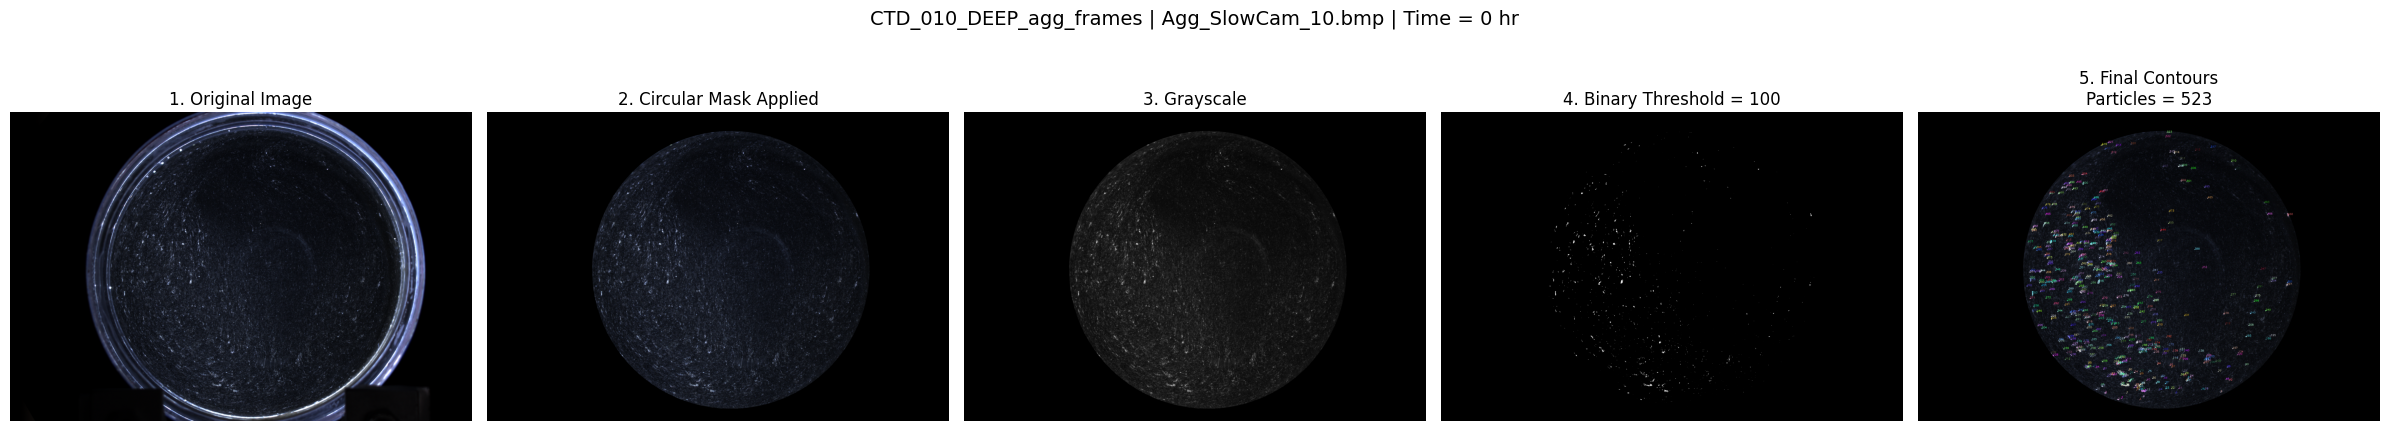


Creating contour check for CTD_010_DEEP_agg_frames, 0.5 hr
Image: Agg_SlowCam_1800.bmp
Saved contour check to: /content/drive/MyDrive/Roller Tank Images/output/contour_checks/CTD_010_DEEP_agg_frames_0p5hr_Agg_SlowCam_1800_contour_check.png


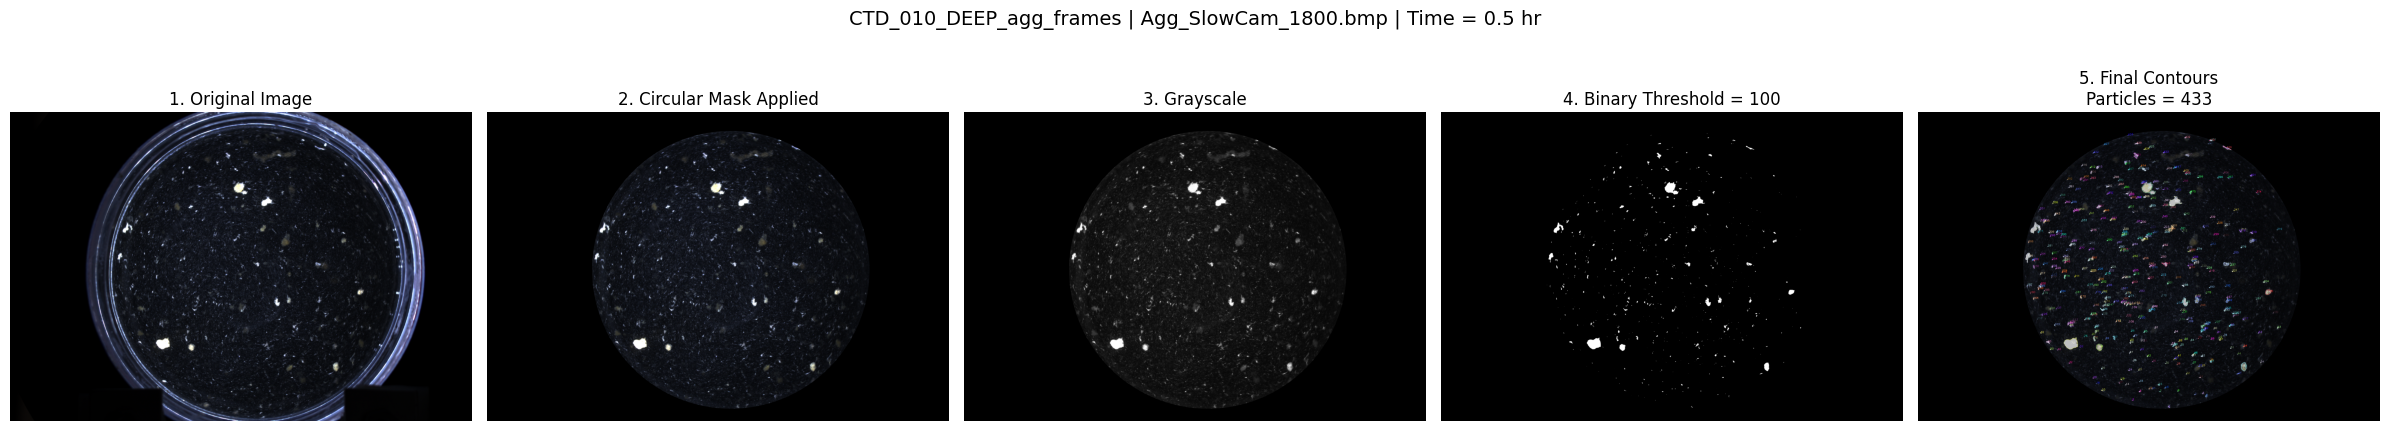


Creating contour check for CTD_010_DEEP_agg_frames, 1 hr
Image: Agg_SlowCam_2700.bmp


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7ef74dd65120> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7ef74df32660> (for post_execute):


KeyboardInterrupt: 

In [37]:
all_particle_data = show_and_save_all_contouring_checks()

### Graphing Average Total Volume over Time for Linear Fit

In [ ]:
def get_graph_output_paths():
    if PROCESSING_MODE == "average60":
        plot_path = output_folder / "all_ctds_linear_fit_60frame_average.png"
        slope_csv_path = output_folder / "ctd_linear_slope_ranking_60frame_average.csv"

    elif PROCESSING_MODE == "single":
        plot_path = output_folder / "all_ctds_linear_fit_singleframe.png"
        slope_csv_path = output_folder / "ctd_linear_slope_ranking_singleframe.csv"

    return plot_path, slope_csv_path


def graph_all_ctds(results_df=None):
    if results_df is None or len(results_df) == 0:
        input_csv_path = get_processed_csv_path()

        if not input_csv_path.exists():
            print(f"No processed data CSV found: {input_csv_path}")
            return pd.DataFrame()

        results_df = pd.read_csv(input_csv_path)

    plot_path, slope_csv_path = get_graph_output_paths()

    fig, ax = plt.subplots(figsize=(14, 8))

    if PROCESSING_MODE == "average60":
        ax.set_title(
            "60-Frame Average Total Volume (mL/L) over time with Linear Fits",
            fontsize=14
        )

    elif PROCESSING_MODE == "single":
        ax.set_title(
            "Single-Frame Total Volume (mL/L) over time with Linear Fits",
            fontsize=14
        )

    slope_results = []

    for CTD_NAME in sorted(results_df["CTD"].unique()):
        ctd_df = results_df[results_df["CTD"] == CTD_NAME].copy()
        ctd_df = ctd_df.sort_values("Time_hr")

        time_points = ctd_df["Time_hr"].to_numpy()
        volume_values = ctd_df["Average_Total_Volume_mL_per_L"].to_numpy()

        if len(time_points) < 2:
            print(f"Skipping {CTD_NAME}: not enough data points")
            continue

        # Raw data
        ax.plot(
            time_points,
            volume_values,
            marker="o",
            linewidth=1,
            label=CTD_NAME
        )

        # Linear fit
        slope, intercept, r_value, p_value, std_err = linregress(
            time_points,
            volume_values
        )

        fit_x = np.linspace(time_points.min(), time_points.max(), 200)
        fit_y = slope * fit_x + intercept

        ax.plot(
            fit_x,
            fit_y,
            linestyle="--",
            linewidth=1
        )

        slope_results.append({
            "CTD": CTD_NAME,
            "Slope_mL_per_L_per_hr": slope,
            "Intercept_mL_per_L": intercept,
            "R_squared": r_value ** 2,
            "P_value": p_value,
            "Std_err": std_err,
            "Number_of_Timepoints": len(time_points)
        })

    if len(slope_results) == 0:
        print("No datasets had enough data for a linear fit.")
        return pd.DataFrame()

    slope_df = pd.DataFrame(slope_results)

    slope_df = slope_df.sort_values(
        by="Slope_mL_per_L_per_hr",
        ascending=False
    ).reset_index(drop=True)

    slope_df.to_csv(slope_csv_path, index=False)

    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Average Total Volume (mL/L)")
    ax.grid(True)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Graph saved to: {plot_path}")
    print(f"Slope ranking CSV saved to: {slope_csv_path}")

    return slope_df

In [ ]:
slope_df = graph_all_ctds(results_df)